## Importação das bibliotecas 

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [18]:
import tensorflow as tf
import matplotlib
import sklearn

print("Versões das Bibliotecas Utilizadas:")
print(f"TensorFlow: {tf.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Scikit-Learn: {sklearn.__version__}")

Versões das Bibliotecas Utilizadas:
TensorFlow: 2.10.0
Matplotlib: 3.7.2
Pandas: 2.0.3
Numpy: 1.24.3
Seaborn: 0.13.2
Scikit-Learn: 1.3.0


## Carregamento do dataset

In [19]:
dataset = pd.read_csv('baseMLJurandir.csv')

X = dataset.iloc[:, :-1].values  
y = dataset.iloc[:, -1].values   
dataset.head()

,saltos,núcleo,modulação,comprimento,primeiro slot,ultimo slot,XT,OSNR,banda,Utilização núcleo 0,Utilização núcleo 1,Utilização núcleo 2,Utilização núcleo 3,Utilização núcleo 4,Utilização núcleo 5,Utilização núcleo 6,resultado
0,1,5,16.0,750.0,1,3,-120.0,18.072260,2.000000e+11,0,0,0,0,0,0,0,1
1,1,5,32.0,600.0,1,2,-120.0,19.041254,2.000000e+11,0,0,0,0,0,0,0,1
2,3,5,4.0,3350.0,1,3,-120.0,11.616460,1.000000e+11,0,0,0,0,0,0,0,1
3,2,5,4.0,2550.0,1,10,-120.0,12.747134,4.000000e+11,0,0,0,0,0,0,0,1
4,3,5,8.0,2250.0,1,2,-120.0,13.322131,1.000000e+11,0,0,0,0,0,0,0,1


## Remoção de registros duplicados

In [20]:
dataset.describe()

,saltos,núcleo,modulação,comprimento,primeiro slot,ultimo slot,XT,OSNR,banda,Utilização núcleo 0,Utilização núcleo 1,Utilização núcleo 2,Utilização núcleo 3,Utilização núcleo 4,Utilização núcleo 5,Utilização núcleo 6,resultado
count,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06,1.107168e+06
mean,2.347283e+00,3.000029e+00,1.196825e+01,1.838604e+03,1.593439e+02,1.622640e+02,-1.031674e+02,1.471766e+01,2.003519e+11,3.977928e+03,1.631526e+03,1.639434e+03,1.631226e+03,1.641314e+03,1.628996e+03,1.640716e+03,8.713086e-01
std,1.038725e+00,1.999995e+00,1.227522e+01,8.436567e+02,1.124487e+02,1.124596e+02,3.744787e+01,2.497246e+00,1.001936e+11,2.500253e+03,9.621360e+02,9.658642e+02,9.605001e+02,9.673401e+02,9.605221e+02,9.687650e+02,3.348582e-01
min,1.000000e+00,0.000000e+00,4.000000e+00,3.000000e+02,1.000000e+00,1.000000e+00,-1.200000e+02,1.142610e+01,1.000000e+11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,1.000000e+00,4.000000e+00,1.100000e+03,4.200000e+01,4.500000e+01,-1.200000e+02,1.274187e+01,1.000000e+11,2.004000e+03,8.700000e+02,8.700000e+02,8.700000e+02,8.760000e+02,8.700000e+02,8.700000e+02,1.000000e+00
50%,2.000000e+00,3.000000e+00,8.000000e+00,1.800000e+03,1.600000e+02,1.620000e+02,-1.200000e+02,1.411949e+01,2.000000e+11,3.600000e+03,1.530000e+03,1.536000e+03,1.530000e+03,1.536000e+03,1.524000e+03,1.536000e+03,1.000000e+00
75%,3.000000e+00,5.000000e+00,1.600000e+01,2.550000e+03,2.770000e+02,2.800000e+02,-1.200000e+02,1.617628e+01,3.000000e+11,5.592000e+03,2.280000e+03,2.298000e+03,2.280000e+03,2.298000e+03,2.280000e+03,2.298000e+03,1.000000e+00
max,5.000000e+00,6.000000e+00,6.400000e+01,3.350000e+03,3.200000e+02,3.200000e+02,0.000000e+00,2.186542e+01,4.000000e+11,1.392600e+04,5.712000e+03,5.586000e+03,5.880000e+03,5.712000e+03,5.646000e+03,5.700000e+03,1.000000e+00


In [21]:
num_registros = dataset.shape[0]
print(f"Número de registros: {num_registros}")

dataset = dataset.drop_duplicates() 

num_registros = dataset.shape[0]
print(f"Número de registros: {num_registros}")


Número de registros: 1107168
Número de registros: 1106878


In [22]:
dataset.describe()

,saltos,núcleo,modulação,comprimento,primeiro slot,ultimo slot,XT,OSNR,banda,Utilização núcleo 0,Utilização núcleo 1,Utilização núcleo 2,Utilização núcleo 3,Utilização núcleo 4,Utilização núcleo 5,Utilização núcleo 6,resultado
count,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06,1.106878e+06
mean,2.347551e+00,3.000097e+00,1.196758e+01,1.838796e+03,1.593473e+02,1.622676e+02,-1.031679e+02,1.471712e+01,2.003551e+11,3.978669e+03,1.631838e+03,1.639746e+03,1.631538e+03,1.641625e+03,1.629307e+03,1.641029e+03,8.713246e-01
std,1.038653e+00,1.999974e+00,1.227636e+01,8.436257e+02,1.124427e+02,1.124535e+02,3.744733e+01,2.497178e+00,1.001949e+11,2.499830e+03,9.619446e+02,9.656684e+02,9.603108e+02,9.671445e+02,9.603336e+02,9.685732e+02,3.348405e-01
min,1.000000e+00,0.000000e+00,4.000000e+00,3.000000e+02,1.000000e+00,1.000000e+00,-1.200000e+02,1.142610e+01,1.000000e+11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,1.000000e+00,4.000000e+00,1.100000e+03,4.200000e+01,4.500000e+01,-1.200000e+02,1.274175e+01,1.000000e+11,2.010000e+03,8.700000e+02,8.700000e+02,8.700000e+02,8.760000e+02,8.700000e+02,8.700000e+02,1.000000e+00
50%,2.000000e+00,3.000000e+00,8.000000e+00,1.800000e+03,1.600000e+02,1.620000e+02,-1.200000e+02,1.411917e+01,2.000000e+11,3.600000e+03,1.530000e+03,1.536000e+03,1.530000e+03,1.536000e+03,1.524000e+03,1.536000e+03,1.000000e+00
75%,3.000000e+00,5.000000e+00,1.600000e+01,2.550000e+03,2.770000e+02,2.800000e+02,-1.200000e+02,1.617546e+01,3.000000e+11,5.592000e+03,2.280000e+03,2.298000e+03,2.280000e+03,2.298000e+03,2.280000e+03,2.298000e+03,1.000000e+00
max,5.000000e+00,6.000000e+00,6.400000e+01,3.350000e+03,3.200000e+02,3.200000e+02,0.000000e+00,2.186542e+01,4.000000e+11,1.392600e+04,5.712000e+03,5.586000e+03,5.880000e+03,5.712000e+03,5.646000e+03,5.700000e+03,1.000000e+00


## Gráficos para análise dos dados

⚠️ **Atenção**: Só execute a célula a seguir se tiver uma boa capacidade de processamento.


sns.set(style="whitegrid", palette="muted")

plt.figure(figsize=(12, 12))
sns.pairplot(dataset, hue='resultado', diag_kind='kde', palette='husl')
plt.suptitle('Pairplot das Features com Resultado', y=1.02)
plt.show()

Text(0, 0.5, 'Número de Exemplos')

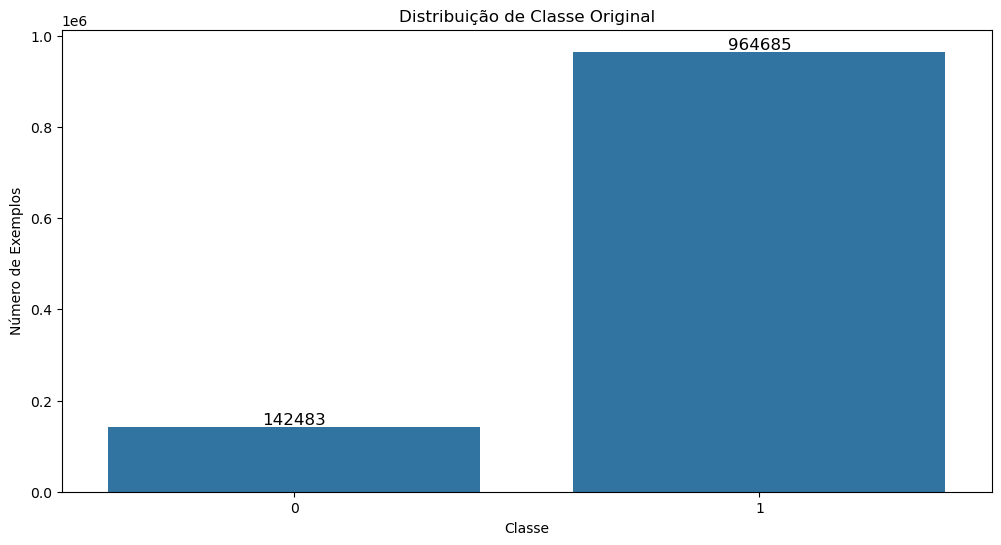

In [23]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=y)
class_counts = np.bincount(y)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title('Distribuição de Classe Original')
plt.xlabel('Classe')
plt.ylabel('Número de Exemplos')

## Gráfico de correlação

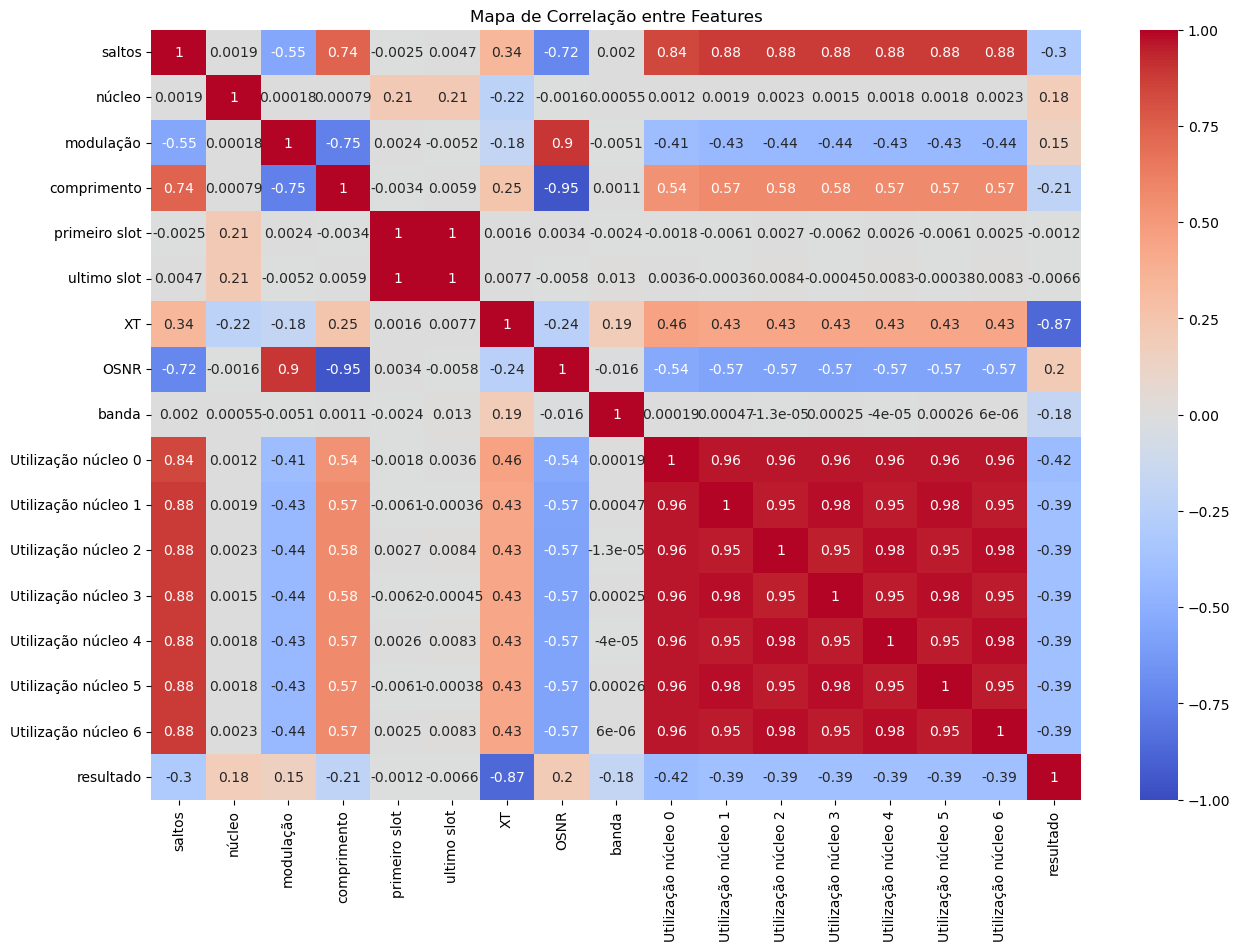

In [24]:
plt.figure(figsize=(15, 10))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Correlação entre Features')
plt.show()

## Histograma dos dados

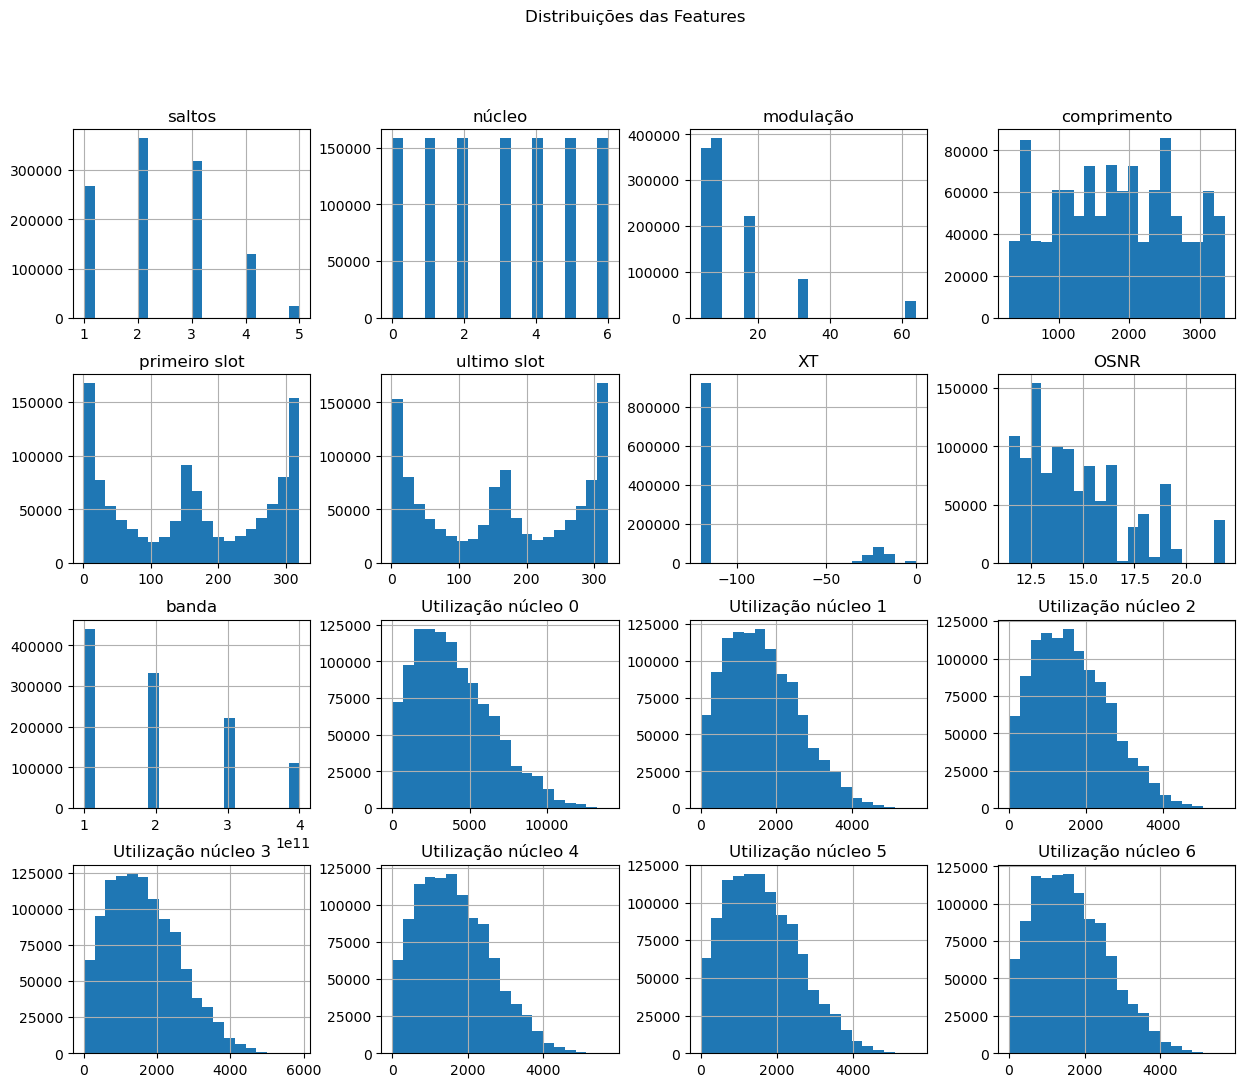

In [25]:
dataset.iloc[:, :-1].hist(figsize=(15, 12), bins=20)
plt.suptitle('Distribuições das Features')
plt.show()

## Padronização dos dados


O **`StandardScaler()`** é uma técnica utilizada no pré-processamento de dados comumente usada para transformar as características dos dados para que elas tenham uma distribuição com **média zero** e **desvio padrão igual a um**. Esse processo é chamado de **padronização** ou **z-score normalization**.

### Equação do **`StandardScaler()`**

A fórmula matemática utilizada pelo `StandardScaler()` é a seguinte:

$$
z = \frac{x - \mu}{\sigma}
$$

x é o valor, 
$\mu$ é a média e 
$\sigma$ σ é o desvio padrão.

In [26]:
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

## Divisão em treino e teste e aplicação de undersampling

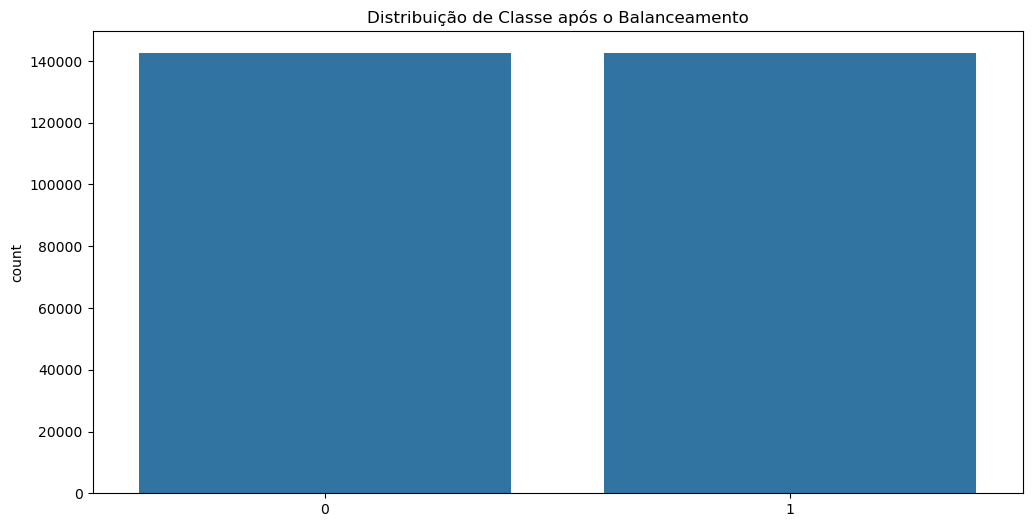

In [27]:
min_class_size = min(np.bincount(y))
X_resampled, y_resampled = [], []
for class_label in np.unique(y):
    X_class = X_standard[y == class_label]
    y_class = y[y == class_label]
    X_class_resampled, y_class_resampled = resample(
        X_class, y_class, replace=False, n_samples=min_class_size, random_state=42)
    X_resampled.append(X_class_resampled)
    y_resampled.append(y_class_resampled)

X_resampled = np.vstack(X_resampled)
y_resampled = np.hstack(y_resampled)

plt.figure(figsize=(12, 6))
sns.countplot(x=y_resampled)
plt.title('Distribuição de Classe após o Balanceamento')
plt.show()

### Divisão em treino e teste

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

## Função para construir o modelo

**Função `create_model`**: Esta função define a arquitetura de uma rede neural usando o Keras.

- **`Sequential()`**: Inicializa o modelo sequencial, onde as camadas são adicionadas uma após a outra.
- **`Dense`**: Adiciona uma camada densa. 
- **`BatchNormalization()`**: Aplica normalização de lote para estabilizar o aprendizado e acelerar o treinamento, reduzindo a variação interna da rede.
- **`Dropout`**: Aplica uma técnica de regularização onde um percentual dos neurônios são descartados aleatoriamente durante o treinamento para evitar overfitting.
- **`model.compile()`**: Compila o modelo, utilizando.
- **`model.summary()`**: Exibe um resumo da arquitetura do modelo, mostrando a quantidade de parâmetros e o formato das camadas.

Este modelo é projetado para tarefas de classificação binária.


In [29]:
def create_model():
    model = Sequential()
    model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

### Configuração de callbacks

**EarlyStopping**: para parar o treinamento antecipadamente quando o desempenho do modelo em um conjunto de validação não melhora mais, prevenindo overfitting.

**ModelCheckpoint**: para salvar o modelo na melhor época durante o treinamento, de acordo com a métrica monitorada.

**ReduceLROnPlateau**: para reduzir a taxa de aprendizado quando a métrica monitorada para de melhorar, ajudando o modelo a fazer ajustes mais finos.


In [30]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint_best = ModelCheckpoint('best_binary_model_BalDiv.h5', monitor='val_loss', save_best_only=True, verbose=1)
checkpoint_last = ModelCheckpoint('last_binary_model_BalDiv.h5', save_best_only=False, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-5)


## Criação do modelo

In [31]:
model = create_model()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                1088      
                                                                 
 batch_normalization_2 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_3 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_3 (Dropout)         (None, 32)               

**Função `model.fit`**: Este comando treina o modelo com os dados de treinamento, ajustando os parâmetros do modelo em cada época.

- **`epochs`**: Define o número de épocas, ou seja, o número de vezes que o modelo irá passar por todo o conjunto de treinamento.
- **`batch_size`**: Define o tamanho do lote, ou seja, o número de amostras que serão processadas antes de atualizar os pesos do modelo.
- **`verbose`**: Controla a quantidade de informações que são exibidas durante o treinamento. O valor 1 exibe uma barra de progresso e informações detalhadas sobre o treinamento.

In [32]:
history = model.fit(
    X_train, y_train, 
    epochs=20, batch_size=32, verbose=1, 
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping, checkpoint_best, checkpoint_last, reduce_lr]
)

Epoch 1/20
6233/6234 [============================>.] - ETA: 0s - loss: 0.1052 - accuracy: 0.9741
Epoch 1: val_loss improved from inf to 0.08297, saving model to best_binary_model_BalDiv.h5

Epoch 1: saving model to last_binary_model_BalDiv.h5
6234/6234 [==============================] - 31s 5ms/step - loss: 0.1052 - accuracy: 0.9741 - val_loss: 0.0830 - val_accuracy: 0.9765 - lr: 0.0010
Epoch 2/20
6234/6234 [==============================] - ETA: 0s - loss: 0.0910 - accuracy: 0.9763
Epoch 2: val_loss improved from 0.08297 to 0.07763, saving model to best_binary_model_BalDiv.h5

Epoch 2: saving model to last_binary_model_BalDiv.h5
6234/6234 [==============================] - 26s 4ms/step - loss: 0.0910 - accuracy: 0.9763 - val_loss: 0.0776 - val_accuracy: 0.9765 - lr: 0.0010
Epoch 3/20
6223/6234 [============================>.] - ETA: 0s - loss: 0.0834 - accuracy: 0.9763
Epoch 3: val_loss improved from 0.07763 to 0.07009, saving model to best_binary_model_BalDiv.h5

Epoch 3: saving mod

## Plotagem de gráficos

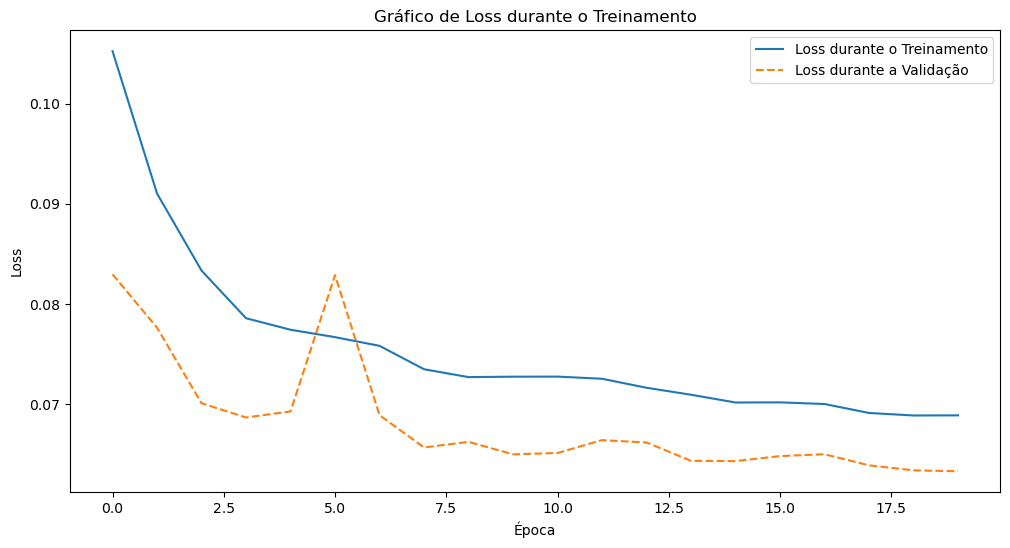

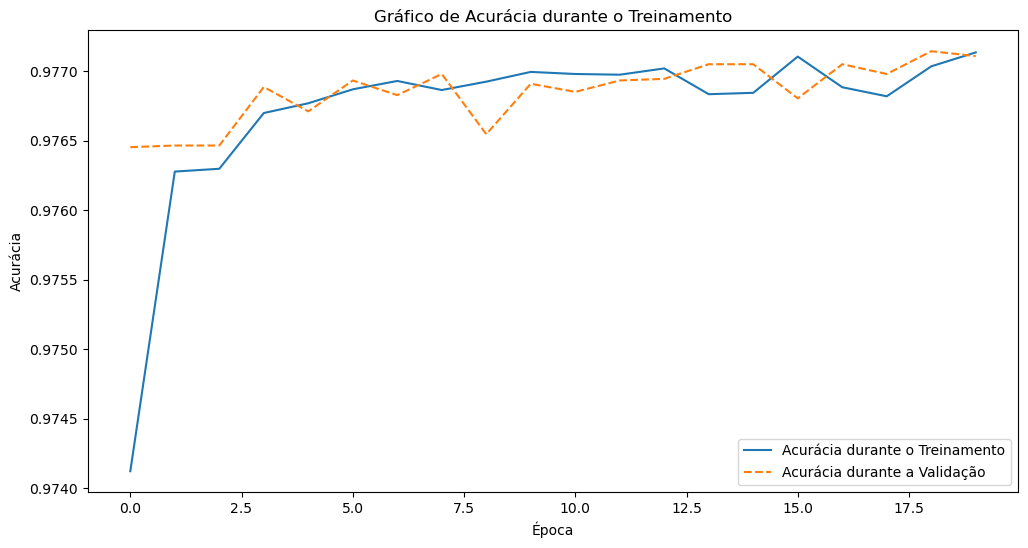

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Loss durante o Treinamento')
plt.plot(history.history['val_loss'], label='Loss durante a Validação', linestyle='--')
plt.title('Gráfico de Loss durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Acurácia durante o Treinamento')
plt.plot(history.history['val_accuracy'], label='Acurácia durante a Validação', linestyle='--')
plt.title('Gráfico de Acurácia durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

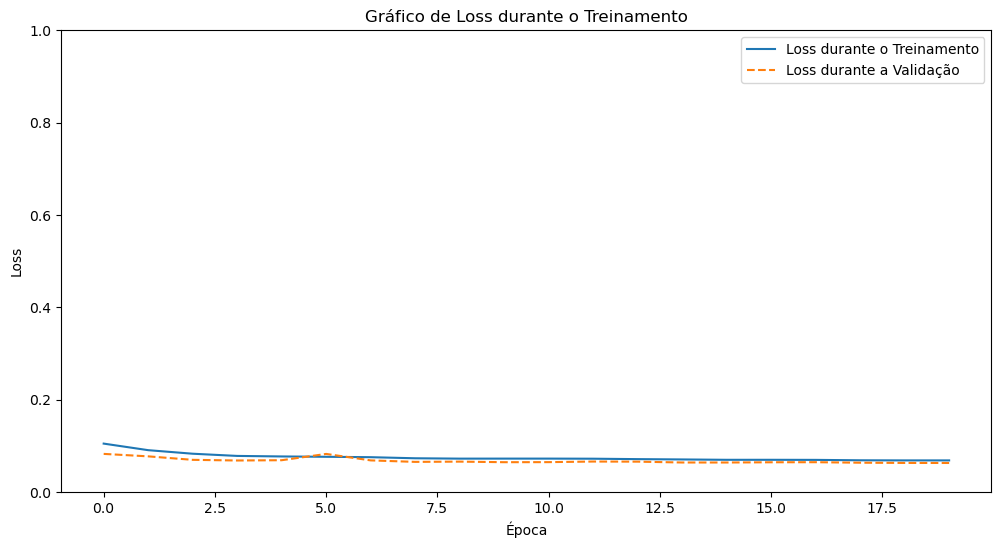

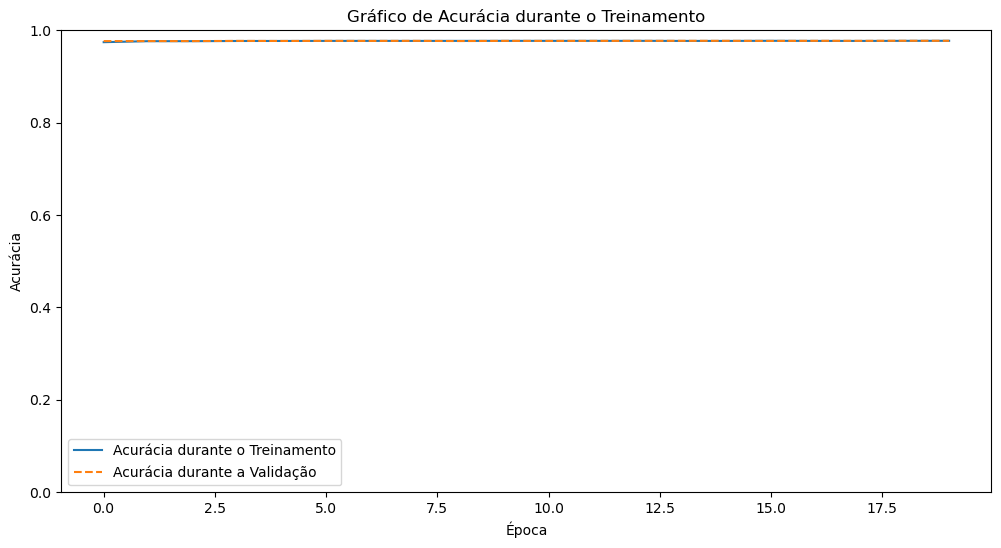

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Loss durante o Treinamento')
plt.plot(history.history['val_loss'], label='Loss durante a Validação', linestyle='--')
plt.title('Gráfico de Loss durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.ylim(0, 1)  
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Acurácia durante o Treinamento')
plt.plot(history.history['val_accuracy'], label='Acurácia durante a Validação', linestyle='--')
plt.title('Gráfico de Acurácia durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.ylim(0, 1)  
plt.legend()
plt.show()


2672/2672 [==============================] - 3s 923us/step


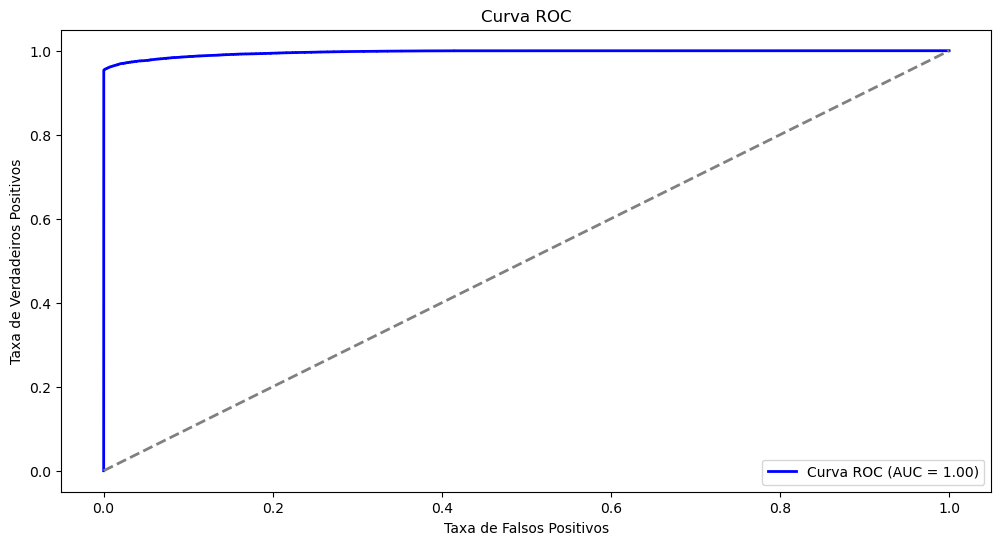

In [35]:
fpr, tpr, _ = roc_curve(y_test, model.predict(X_test))
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.legend(loc="lower right")
plt.show()

## Mais avaliações e plotagens alcançadas

In [36]:
y_pred_train = (model.predict(X_train) > 0.5).astype("int32")
y_pred_test = (model.predict(X_test) > 0.5).astype("int32")

conf_matrix_train = confusion_matrix(y_train, y_pred_train)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)

print("Classification Report - Treino:")
print(classification_report(y_train, y_pred_train))
print("Classification Report - Teste:")
print(classification_report(y_test, y_pred_test))

2672/2672 [==============================] - 3s 942us/step
Classification Report - Treino:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     99897
           1       1.00      0.96      0.98     99579

    accuracy                           0.98    199476
   macro avg       0.98      0.98      0.98    199476
weighted avg       0.98      0.98      0.98    199476

Classification Report - Teste:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     42586
           1       1.00      0.96      0.98     42904

    accuracy                           0.98     85490
   macro avg       0.98      0.98      0.98     85490
weighted avg       0.98      0.98      0.98     85490



## Matrizes de confusão

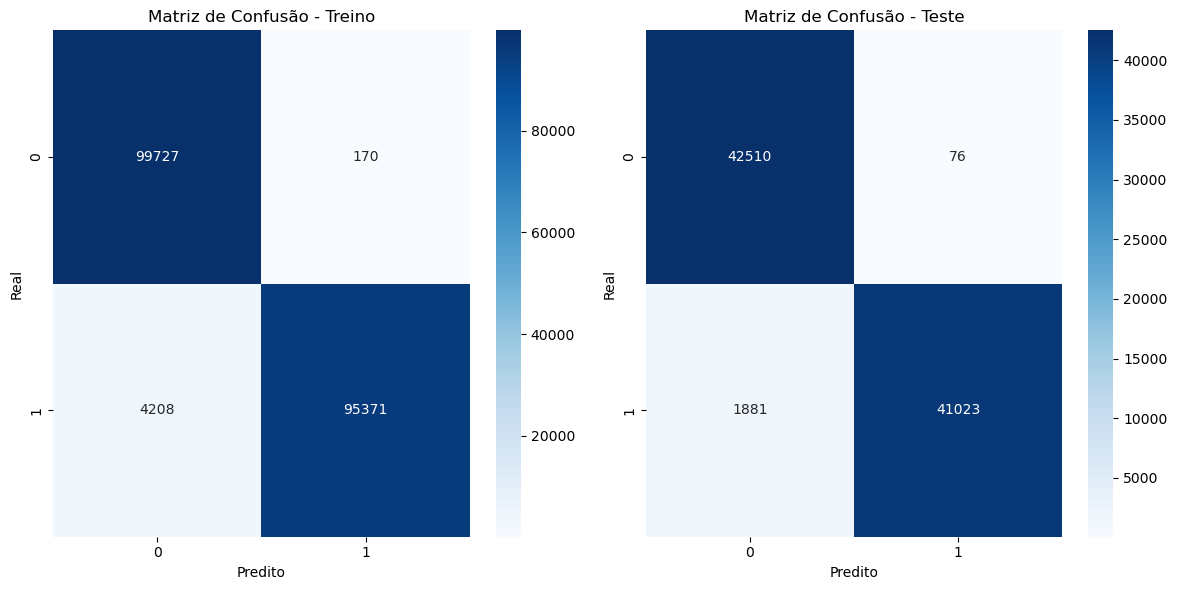

In [37]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_train, annot=True, cmap='Blues', fmt='g')
plt.title('Matriz de Confusão - Treino')
plt.xlabel('Predito')
plt.ylabel('Real')

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test, annot=True, cmap='Blues', fmt='g')
plt.title('Matriz de Confusão - Teste')
plt.xlabel('Predito')
plt.ylabel('Real')

plt.tight_layout()
plt.show()